# Klasifikasi Penyakit Daun Anggur — EfficientNet-B0

Notebook final untuk melatih classifier 3 kelas dari citra daun yang sudah dimasking dengan background hitam. Model dipilih berdasarkan validation macro F1, lalu dievaluasi sekali pada test set.


## 1. Setup


In [1]:
!pip -q install timm==0.9.12

In [2]:
import json
import random
import time
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import timm
from torchvision import transforms
from google.colab import drive

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

Torch: 2.11.0+cu128
CUDA available: True


## 2. Konfigurasi


In [3]:
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
ROOT_DIR = Path('/content/drive/MyDrive/SkripsiFinal')
DATASET_DIR = ROOT_DIR / 'datasets/dataset_klasifikasi/klasifikasi_masked'

MODEL_NAME = 'klasifikasi_penyakit_final'
MODEL_DIR = ROOT_DIR / 'models' / MODEL_NAME
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / f'{MODEL_NAME}_best.pth'
LAST_MODEL_PATH = MODEL_DIR / f'{MODEL_NAME}_last.pth'
CONFIG_PATH = MODEL_DIR / f'{MODEL_NAME}_config.json'
HISTORY_CSV = MODEL_DIR / f'{MODEL_NAME}_training_history.csv'
TEST_PRED_CSV = MODEL_DIR / f'{MODEL_NAME}_test_predictions.csv'
CURVE_PATH = MODEL_DIR / f'{MODEL_NAME}_training_curves.png'
CONFUSION_MATRIX_PATH = MODEL_DIR / f'{MODEL_NAME}_confusion_matrix.png'

CLASS_NAMES = ['Black_Measles', 'Black_Rot', 'Isariopsis_Leaf_Spot']
NUM_CLASSES = len(CLASS_NAMES)

In [5]:
BACKBONE_NAME = 'efficientnet_b0'
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
SEED = 42

STAGE1_EPOCHS = 8
STAGE2_EPOCHS = 25
STAGE1_LR = 5e-4
STAGE2_LR = 1e-5

WEIGHT_DECAY = 1e-4
DROPOUT = 0.50
LABEL_SMOOTHING = 0.05
USE_CLASS_WEIGHTS = True

GRAD_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 7
MIN_DELTA = 1e-4

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_seed(SEED)


## 3. Dataset dan Transform


In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12,
        saturation=0.08,
        hue=0.02,
    ),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
    ], p=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


In [7]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}


class MaskedLeafClassificationDataset(Dataset):
    def __init__(self, dataset_dir, split, class_names, transform=None):
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.class_names = list(class_names)
        self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}
        self.transform = transform
        self.samples = self._load_samples()

    def _load_samples(self):
        split_dir = self.dataset_dir / self.split
        if not split_dir.exists():
            raise FileNotFoundError(f'Folder split tidak ditemukan: {split_dir}')

        samples = []
        for class_name in self.class_names:
            class_dir = split_dir / class_name
            if not class_dir.exists():
                raise FileNotFoundError(f'Folder kelas tidak ditemukan: {class_dir}')

            image_paths = sorted([
                path for path in class_dir.rglob('*')
                if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
            ])

            label = self.class_to_idx[class_name]
            samples.extend([(path, label) for path in image_paths])

        if len(samples) == 0:
            raise RuntimeError(f'Tidak ada gambar pada split: {self.split}')

        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]
        image = Image.open(image_path).convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        return image, label, str(image_path)


def summarize_dataset(dataset):
    counter = Counter(label for _, label in dataset.samples)
    return {CLASS_NAMES[idx]: counter[idx] for idx in range(NUM_CLASSES)}


In [8]:
train_dataset = MaskedLeafClassificationDataset(DATASET_DIR, 'train', CLASS_NAMES, train_transform)
val_dataset = MaskedLeafClassificationDataset(DATASET_DIR, 'val', CLASS_NAMES, eval_transform)
test_dataset = MaskedLeafClassificationDataset(DATASET_DIR, 'test', CLASS_NAMES, eval_transform)

dataset_summary = pd.DataFrame([
    {'split': 'train', 'jumlah_data': len(train_dataset), **summarize_dataset(train_dataset)},
    {'split': 'val', 'jumlah_data': len(val_dataset), **summarize_dataset(val_dataset)},
    {'split': 'test', 'jumlah_data': len(test_dataset), **summarize_dataset(test_dataset)},
])

display(dataset_summary)


,split,jumlah_data,Black_Measles,Black_Rot,Isariopsis_Leaf_Spot
0,train,2228,859,722,647
1,val,478,184,155,139
2,test,478,184,155,139


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == 'cuda'),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == 'cuda'),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == 'cuda'),
)


## 4. Cek Sampel Input


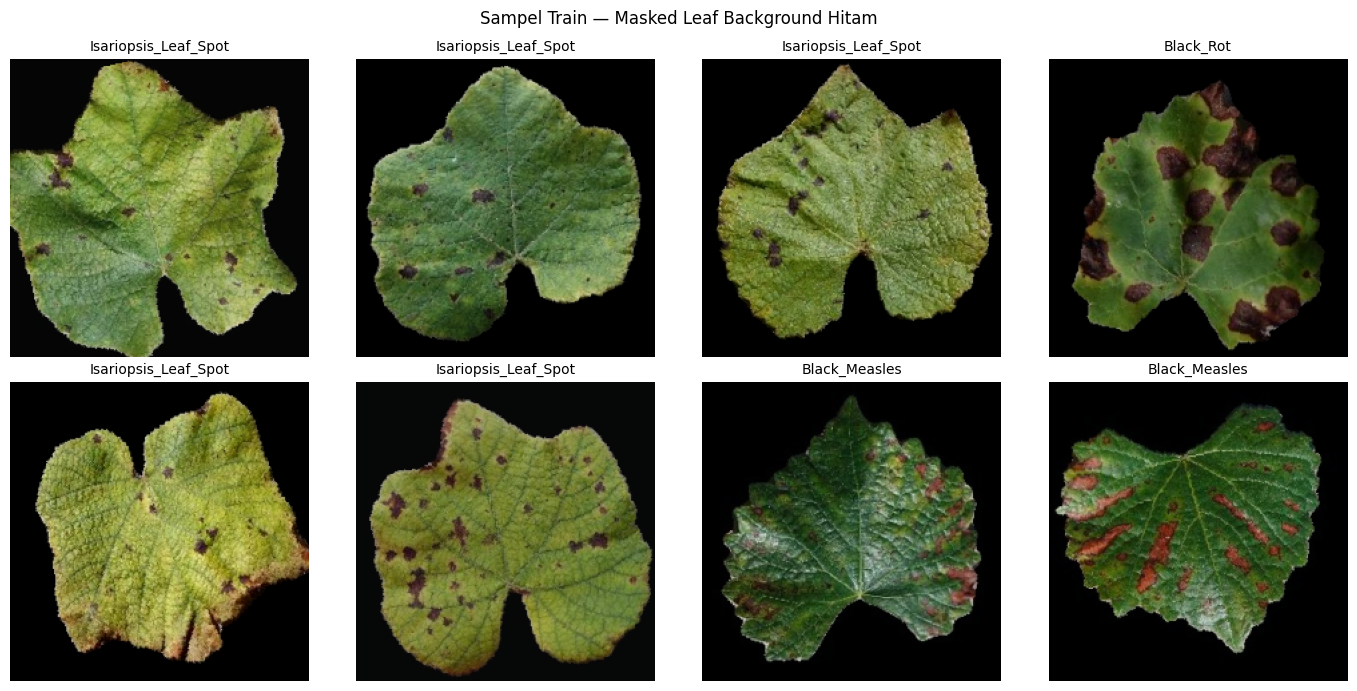

In [10]:
def denormalize(image_tensor):
    image = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = image * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(image, 0, 1)


images, labels, _ = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

for i in range(min(8, len(images))):
    axes[i].imshow(denormalize(images[i]))
    axes[i].set_title(CLASS_NAMES[int(labels[i])], fontsize=10)
    axes[i].axis('off')

for ax in axes:
    ax.axis('off')

plt.suptitle('Sampel Train — Masked Leaf Background Hitam')
plt.tight_layout()
plt.show()


## 5. Model


In [11]:
class EfficientNetB0Classifier(nn.Module):
    def __init__(self, num_classes, dropout):
        super().__init__()

        self.backbone = timm.create_model(
            BACKBONE_NAME,
            pretrained=True,
            num_classes=0,
            global_pool='avg',
        )

        feature_dim = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(feature_dim),
            nn.Dropout(dropout),
            nn.Linear(feature_dim, num_classes),
        )

    def forward(self, images):
        features = self.backbone(images)
        return self.classifier(features)

    def freeze_backbone(self):
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False

    def unfreeze_backbone(self):
        for parameter in self.backbone.parameters():
            parameter.requires_grad = True


model = EfficientNetB0Classifier(NUM_CLASSES, DROPOUT).to(DEVICE)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [12]:
def build_class_weights(dataset):
    counter = Counter(label for _, label in dataset.samples)
    total = sum(counter.values())

    weights = [
        total / (NUM_CLASSES * counter[idx])
        for idx in range(NUM_CLASSES)
    ]

    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


class_weights = build_class_weights(train_dataset) if USE_CLASS_WEIGHTS else None

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING,
)


## 6. Fungsi Training dan Evaluasi


In [13]:
def compute_metrics(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='macro',
        zero_division=0,
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0,
    )

    return {
        'acc': accuracy_score(y_true, y_pred),
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
    }


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_true = []
    all_pred = []
    all_prob = []
    all_path = []

    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for images, labels, paths in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                if GRAD_CLIP_NORM is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                optimizer.step()

            probabilities = torch.softmax(logits, dim=1)
            predictions = probabilities.argmax(dim=1)

            total_loss += loss.item() * images.size(0)
            all_true.extend(labels.detach().cpu().numpy().tolist())
            all_pred.extend(predictions.detach().cpu().numpy().tolist())
            all_prob.extend(probabilities.detach().cpu().numpy().tolist())
            all_path.extend(paths)

    metrics = compute_metrics(all_true, all_pred)
    metrics['loss'] = total_loss / len(loader.dataset)

    return metrics, np.array(all_true), np.array(all_pred), np.array(all_prob), all_path


def save_checkpoint(path, model, optimizer, epoch, stage, val_metrics, history):
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': epoch,
        'stage': stage,
        'val_metrics': val_metrics,
        'history': dict(history),
        'class_names': CLASS_NAMES,
    }
    torch.save(checkpoint, path)


def load_checkpoint(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


def update_history(history, stage, train_metrics, val_metrics, lr):
    for key, value in train_metrics.items():
        history[f'train_{key}'].append(value)

    for key, value in val_metrics.items():
        history[f'val_{key}'].append(value)

    history['stage'].append(stage)
    history['lr'].append(lr)


def print_metrics(label, metrics):
    print(
        f"{label:<6} "
        f"loss={metrics['loss']:.4f} | "
        f"acc={metrics['acc']:.4f} | "
        f"macro_f1={metrics['f1_macro']:.4f} | "
        f"precision={metrics['precision_macro']:.4f} | "
        f"recall={metrics['recall_macro']:.4f}"
    )


## 7. Training Stage 1 — Train Classifier Head


In [14]:
history = defaultdict(list)
best_val_f1 = -1.0
best_epoch = 0
best_stage = None

model.freeze_backbone()

optimizer = torch.optim.AdamW(
    filter(lambda parameter: parameter.requires_grad, model.parameters()),
    lr=STAGE1_LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, STAGE1_EPOCHS),
    eta_min=STAGE1_LR * 0.1,
)

for epoch in range(1, STAGE1_EPOCHS + 1):
    start_time = time.time()

    train_metrics, *_ = run_epoch(model, train_loader, criterion, optimizer)
    val_metrics, *_ = run_epoch(model, val_loader, criterion)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    update_history(history, 'stage1', train_metrics, val_metrics, current_lr)

    is_best = val_metrics['f1_macro'] > best_val_f1 + MIN_DELTA
    if is_best:
        best_val_f1 = val_metrics['f1_macro']
        best_epoch = epoch
        best_stage = 'stage1'
        save_checkpoint(BEST_MODEL_PATH, model, optimizer, epoch, best_stage, val_metrics, history)

    marker = 'best' if is_best else ''
    print(f'Epoch {epoch:02d}/{STAGE1_EPOCHS} | {time.time() - start_time:.1f}s | {marker}')
    print_metrics('Train', train_metrics)
    print_metrics('Val', val_metrics)


Epoch 01/8 | 26.5s | best
Train  loss=0.5674 | acc=0.7935 | macro_f1=0.7959 | precision=0.7936 | recall=0.7997
Val    loss=0.3388 | acc=0.9310 | macro_f1=0.9341 | precision=0.9345 | recall=0.9339
Epoch 02/8 | 35.6s | best
Train  loss=0.3842 | acc=0.9031 | macro_f1=0.9060 | precision=0.9045 | recall=0.9079
Val    loss=0.3205 | acc=0.9393 | macro_f1=0.9426 | precision=0.9424 | recall=0.9427
Epoch 03/8 | 25.7s | best
Train  loss=0.3699 | acc=0.9125 | macro_f1=0.9152 | precision=0.9139 | recall=0.9169
Val    loss=0.3099 | acc=0.9519 | macro_f1=0.9544 | precision=0.9549 | recall=0.9539
Epoch 04/8 | 24.6s | best
Train  loss=0.3427 | acc=0.9246 | macro_f1=0.9276 | precision=0.9269 | recall=0.9285
Val    loss=0.3044 | acc=0.9603 | macro_f1=0.9623 | precision=0.9633 | recall=0.9615
Epoch 05/8 | 25.3s | 
Train  loss=0.3434 | acc=0.9259 | macro_f1=0.9292 | precision=0.9285 | recall=0.9310
Val    loss=0.3012 | acc=0.9582 | macro_f1=0.9604 | precision=0.9604 | recall=0.9604
Epoch 06/8 | 26.1s | bes

## 8. Training Stage 2 — Fine-tuning


In [15]:
checkpoint = load_checkpoint(BEST_MODEL_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
model.unfreeze_backbone()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=STAGE2_LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
)

patience_counter = 0

for epoch in range(1, STAGE2_EPOCHS + 1):
    start_time = time.time()
    global_epoch = STAGE1_EPOCHS + epoch

    train_metrics, *_ = run_epoch(model, train_loader, criterion, optimizer)
    val_metrics, *_ = run_epoch(model, val_loader, criterion)

    scheduler.step(val_metrics['f1_macro'])
    current_lr = optimizer.param_groups[0]['lr']
    update_history(history, 'stage2', train_metrics, val_metrics, current_lr)

    is_best = val_metrics['f1_macro'] > best_val_f1 + MIN_DELTA
    if is_best:
        best_val_f1 = val_metrics['f1_macro']
        best_epoch = global_epoch
        best_stage = 'stage2'
        patience_counter = 0
        save_checkpoint(BEST_MODEL_PATH, model, optimizer, global_epoch, best_stage, val_metrics, history)
    else:
        patience_counter += 1

    save_checkpoint(LAST_MODEL_PATH, model, optimizer, global_epoch, 'stage2', val_metrics, history)

    marker = 'best' if is_best else ''
    print(f'Epoch {global_epoch:02d} | stage2 {epoch:02d}/{STAGE2_EPOCHS} | {time.time() - start_time:.1f}s | {marker}')
    print_metrics('Train', train_metrics)
    print_metrics('Val', val_metrics)
    print(f'LR={current_lr:.2e} | patience={patience_counter}/{EARLY_STOPPING_PATIENCE}')

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print('Early stopping.')
        break

print(f'Best model: {best_stage}, epoch {best_epoch}, val_macro_f1={best_val_f1:.4f}')


Epoch 09 | stage2 01/25 | 29.7s | 
Train  loss=0.3279 | acc=0.9336 | macro_f1=0.9358 | precision=0.9357 | recall=0.9361
Val    loss=0.2774 | acc=0.9686 | macro_f1=0.9702 | precision=0.9708 | recall=0.9698
LR=1.00e-05 | patience=1/7
Epoch 10 | stage2 02/25 | 30.0s | 
Train  loss=0.3077 | acc=0.9457 | macro_f1=0.9482 | precision=0.9477 | recall=0.9486
Val    loss=0.2657 | acc=0.9686 | macro_f1=0.9702 | precision=0.9708 | recall=0.9698
LR=1.00e-05 | patience=2/7
Epoch 11 | stage2 03/25 | 30.6s | best
Train  loss=0.3087 | acc=0.9452 | macro_f1=0.9474 | precision=0.9475 | recall=0.9474
Val    loss=0.2582 | acc=0.9728 | macro_f1=0.9742 | precision=0.9744 | recall=0.9741
LR=1.00e-05 | patience=0/7
Epoch 12 | stage2 04/25 | 32.0s | 
Train  loss=0.2808 | acc=0.9632 | macro_f1=0.9645 | precision=0.9639 | recall=0.9652
Val    loss=0.2498 | acc=0.9728 | macro_f1=0.9742 | precision=0.9744 | recall=0.9741
LR=1.00e-05 | patience=1/7
Epoch 13 | stage2 05/25 | 31.4s | best
Train  loss=0.2765 | acc=0.96

## 9. Kurva Training


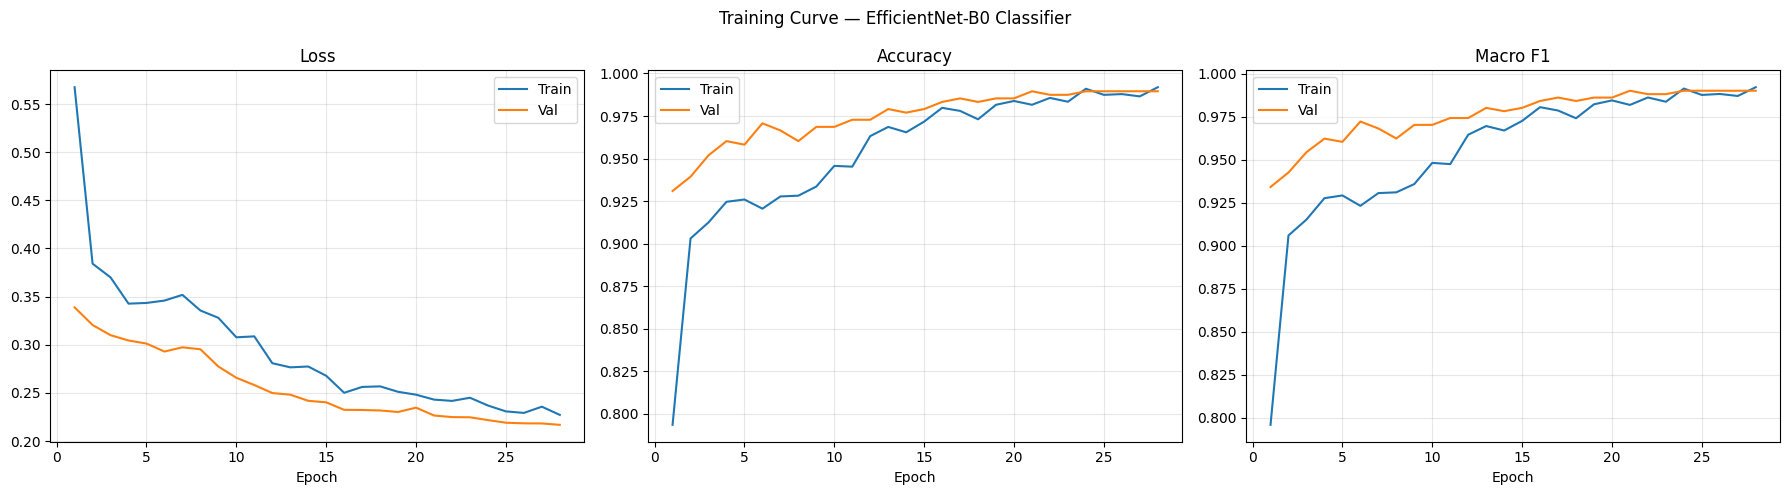

In [16]:
history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_CSV, index=False)

epochs = np.arange(1, len(history_df) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, history_df['train_loss'], label='Train')
axes[0].plot(epochs, history_df['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, history_df['train_acc'], label='Train')
axes[1].plot(epochs, history_df['val_acc'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(epochs, history_df['train_f1_macro'], label='Train')
axes[2].plot(epochs, history_df['val_f1_macro'], label='Val')
axes[2].set_title('Macro F1')
axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.suptitle('Training Curve — EfficientNet-B0 Classifier')
plt.tight_layout()
plt.savefig(CURVE_PATH, dpi=150, bbox_inches='tight')
plt.show()


## 10. Evaluasi Akhir pada Test Set


In [17]:
checkpoint = load_checkpoint(BEST_MODEL_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(DEVICE)
model.eval()

test_metrics, y_true, y_pred, y_prob, test_paths = run_epoch(model, test_loader, criterion)

print('Best checkpoint:')
print(f"stage: {checkpoint.get('stage')}")
print(f"epoch: {checkpoint.get('epoch')}")
print(f"val_macro_f1: {checkpoint.get('val_metrics', {}).get('f1_macro'):.4f}")

print_metrics('Test', test_metrics)

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))


Best checkpoint:
stage: stage2
epoch: 21
val_macro_f1: 0.9901
Test   loss=0.2108 | acc=0.9916 | macro_f1=0.9921 | precision=0.9918 | recall=0.9924
                      precision    recall  f1-score   support

       Black_Measles     0.9945    0.9837    0.9891       184
           Black_Rot     0.9809    0.9935    0.9872       155
Isariopsis_Leaf_Spot     1.0000    1.0000    1.0000       139

            accuracy                         0.9916       478
           macro avg     0.9918    0.9924    0.9921       478
        weighted avg     0.9917    0.9916    0.9916       478



In [18]:
prediction_rows = []

for image_path, true_idx, pred_idx, probability in zip(test_paths, y_true, y_pred, y_prob):
    row = {
        'path': image_path,
        'true_idx': int(true_idx),
        'true_class': CLASS_NAMES[int(true_idx)],
        'pred_idx': int(pred_idx),
        'pred_class': CLASS_NAMES[int(pred_idx)],
        'correct': bool(true_idx == pred_idx),
        'confidence': float(np.max(probability)),
    }

    for class_idx, class_name in enumerate(CLASS_NAMES):
        row[f'prob_{class_name}'] = float(probability[class_idx])

    prediction_rows.append(row)

pred_df = pd.DataFrame(prediction_rows)
pred_df.to_csv(TEST_PRED_CSV, index=False)

display(pred_df.head())


,path,true_idx,true_class,pred_idx,pred_class,correct,confidence,prob_Black_Measles,prob_Black_Rot,prob_Isariopsis_Leaf_Spot
0,/content/drive/MyDrive/SkripsiFinal/datasets/d...,0,Black_Measles,0,Black_Measles,True,0.939953,0.939953,0.047433,0.012613
1,/content/drive/MyDrive/SkripsiFinal/datasets/d...,0,Black_Measles,0,Black_Measles,True,0.943663,0.943663,0.049795,0.006543
2,/content/drive/MyDrive/SkripsiFinal/datasets/d...,0,Black_Measles,0,Black_Measles,True,0.962935,0.962935,0.010764,0.026301
3,/content/drive/MyDrive/SkripsiFinal/datasets/d...,0,Black_Measles,0,Black_Measles,True,0.926586,0.926586,0.002867,0.070547
4,/content/drive/MyDrive/SkripsiFinal/datasets/d...,0,Black_Measles,0,Black_Measles,True,0.773532,0.773532,0.025780,0.200688


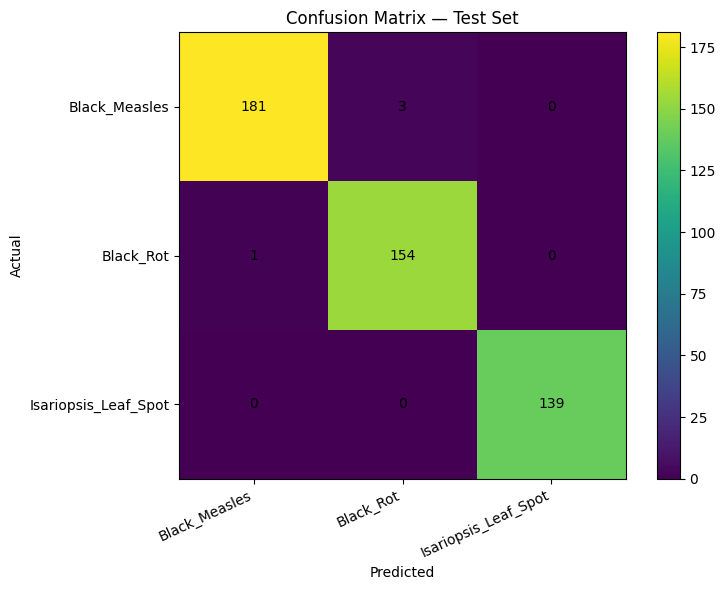

,class,test_samples,accuracy
0,Black_Measles,184,0.983696
1,Black_Rot,155,0.993548
2,Isariopsis_Leaf_Spot,139,1.000000


In [19]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(cm)

ax.set_xticks(np.arange(NUM_CLASSES))
ax.set_yticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Test Set')

for row_idx in range(NUM_CLASSES):
    for col_idx in range(NUM_CLASSES):
        ax.text(col_idx, row_idx, str(cm[row_idx, col_idx]), ha='center', va='center')

fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=150, bbox_inches='tight')
plt.show()

per_class_rows = []
for class_idx, class_name in enumerate(CLASS_NAMES):
    class_mask = y_true == class_idx
    class_acc = (y_pred[class_mask] == class_idx).mean() if class_mask.sum() > 0 else 0.0

    per_class_rows.append({
        'class': class_name,
        'test_samples': int(class_mask.sum()),
        'accuracy': float(class_acc),
    })

per_class_df = pd.DataFrame(per_class_rows)
display(per_class_df)


## 11. Audit Prediksi Salah


,path,true_idx,true_class,pred_idx,pred_class,correct,confidence,prob_Black_Measles,prob_Black_Rot,prob_Isariopsis_Leaf_Spot
178,/content/drive/MyDrive/SkripsiFinal/datasets/d...,0,Black_Measles,1,Black_Rot,False,0.593617,0.396268,0.593617,0.010115
83,/content/drive/MyDrive/SkripsiFinal/datasets/d...,0,Black_Measles,1,Black_Rot,False,0.584280,0.386801,0.584280,0.028919
191,/content/drive/MyDrive/SkripsiFinal/datasets/d...,1,Black_Rot,0,Black_Measles,False,0.511007,0.511007,0.474797,0.014196
45,/content/drive/MyDrive/SkripsiFinal/datasets/d...,0,Black_Measles,1,Black_Rot,False,0.490076,0.484700,0.490076,0.025223


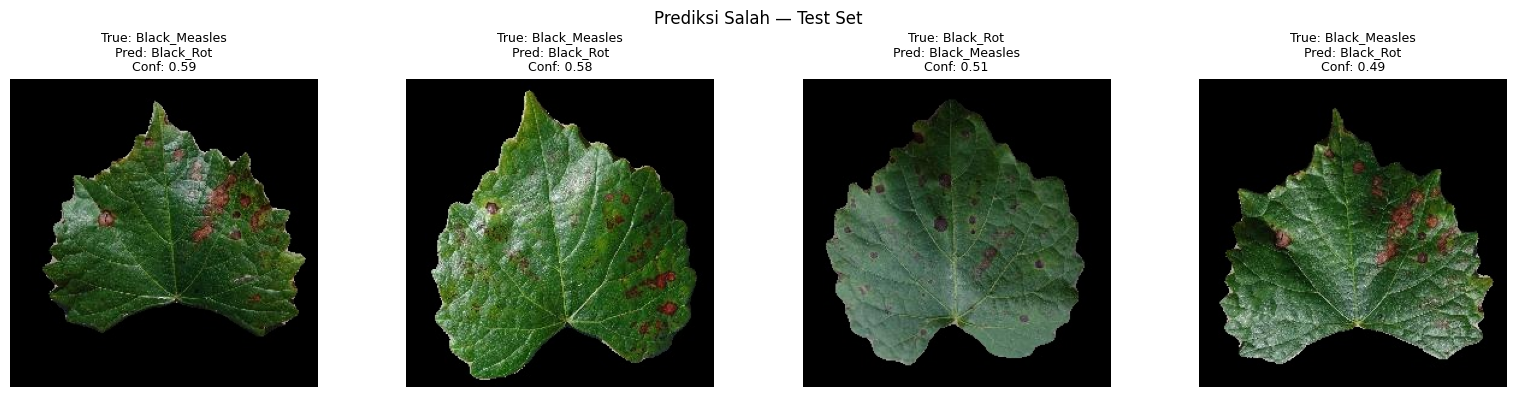

In [20]:
wrong_df = pred_df[~pred_df['correct']].copy()
wrong_df = wrong_df.sort_values('confidence', ascending=False)

display(wrong_df.head(20))

num_images = min(12, len(wrong_df))

if num_images > 0:
    num_cols = 4
    num_rows = int(np.ceil(num_images / num_cols))

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis('off')

    for idx, (_, row) in enumerate(wrong_df.head(num_images).iterrows()):
        image = Image.open(row['path']).convert('RGB')
        axes[idx].imshow(image)
        axes[idx].set_title(
            f"True: {row['true_class']}\nPred: {row['pred_class']}\nConf: {row['confidence']:.2f}",
            fontsize=9,
        )
        axes[idx].axis('off')

    plt.suptitle('Prediksi Salah — Test Set')
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada prediksi salah pada test set.')


## 12. Inference Satu Gambar Masked


In [21]:
def predict_masked_image(image_path, model=model):
    model.eval()

    image = Image.open(image_path).convert('RGB')
    input_tensor = eval_transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(input_tensor)
        probabilities = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    pred_idx = int(np.argmax(probabilities))

    return {
        'pred_idx': pred_idx,
        'pred_class': CLASS_NAMES[pred_idx],
        'confidence': float(probabilities[pred_idx]),
        'probabilities': {
            class_name: float(probabilities[idx])
            for idx, class_name in enumerate(CLASS_NAMES)
        },
    }


## 13. Simpan Config Final


In [ ]:
final_config = {
    'model_name': MODEL_NAME,
    'backbone_name': BACKBONE_NAME,
    'architecture': 'EfficientNet-B0 classifier',
    'dataset_dir': str(DATASET_DIR),
    'input_type': 'masked_leaf_bgblack',
    'class_names': CLASS_NAMES,
    'class_to_idx': {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)},
    'idx_to_class': {str(idx): class_name for idx, class_name in enumerate(CLASS_NAMES)},
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'stage1_epochs': STAGE1_EPOCHS,
    'stage2_epochs': STAGE2_EPOCHS,
    'stage1_lr': STAGE1_LR,
    'stage2_lr': STAGE2_LR,
    'weight_decay': WEIGHT_DECAY,
    'dropout': DROPOUT,
    'label_smoothing': LABEL_SMOOTHING,
    'use_class_weights': USE_CLASS_WEIGHTS,
    'grad_clip_norm': GRAD_CLIP_NORM,
    'early_stopping_patience': EARLY_STOPPING_PATIENCE,
    'seed': SEED,
    'selection_metric': 'val_macro_f1',
    'best_stage': checkpoint.get('stage'),
    'best_epoch': checkpoint.get('epoch'),
    'best_val_metrics': checkpoint.get('val_metrics'),
    'test_metrics': test_metrics,
    'best_model_path': str(BEST_MODEL_PATH),
    'last_model_path': str(LAST_MODEL_PATH),
    'history_csv': str(HISTORY_CSV),
    'test_predictions_csv': str(TEST_PRED_CSV),
    'training_curves_png': str(CURVE_PATH),
    'confusion_matrix_png': str(CONFUSION_MATRIX_PATH),
}

with open(CONFIG_PATH, 'w') as file:
    json.dump(final_config, file, indent=2)

print(f'Config saved: {CONFIG_PATH}')
